In [1]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [2]:
import xarray as xr
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import seaborn as sns
import os
import matplotlib.pyplot as plt

In [3]:
# loading data
CSV_PATH = "/content/drive/MyDrive/EC-Earth3_SSP245_WesternGhats_pr_2025_2100.csv"

pr_df = pd.read_csv(CSV_PATH)

In [4]:
pr_df.head()

,time,lat,lon,pr_mm_day
0,2025-01-01 12:00:00,8.125,73.125,NaN
1,2025-01-01 12:00:00,8.125,73.375,NaN
2,2025-01-01 12:00:00,8.125,73.625,NaN
3,2025-01-01 12:00:00,8.125,73.875,NaN
4,2025-01-01 12:00:00,8.125,74.125,NaN


In [5]:
grid_points = pr_df[["lat", "lon"]].drop_duplicates()


In [6]:


pr_points = gpd.GeoDataFrame(
    grid_points,
    geometry=gpd.points_from_xy(grid_points.lon, grid_points.lat),
    crs="EPSG:4326"
)


### Spatial Filtering to the Western Ghats
To restrict the analysis to the Western Ghats region, latitude–longitude grid points will be converted into spatial point geometries and overlaid with a Western Ghats boundary dataset (GeoJSON). Only grid points whose centroids fall within the Western Ghats boundary will be retained.

In [7]:
wg = gpd.read_file(r"/content/drive/MyDrive/western_Ghats_Boundary.geojson").to_crs(epsg=4326)




In [8]:
grid_wg = gpd.sjoin(
    pr_points,
    wg,
    how="inner",
    predicate="within"
)

In [9]:
valid_points = grid_wg[["lat", "lon"]]


In [10]:
df_wg = pr_df.merge(valid_points, on=["lat", "lon"], how="inner")

In [ ]:
df_wg.head()

,time,lat,lon,pr_mm_day
0,2025-01-01 12:00:00,8.375,77.375,0.0
1,2025-01-01 12:00:00,8.625,77.125,0.0
2,2025-01-01 12:00:00,8.625,77.375,0.0
3,2025-01-01 12:00:00,8.875,77.125,0.0
4,2025-01-01 12:00:00,9.125,77.125,0.0


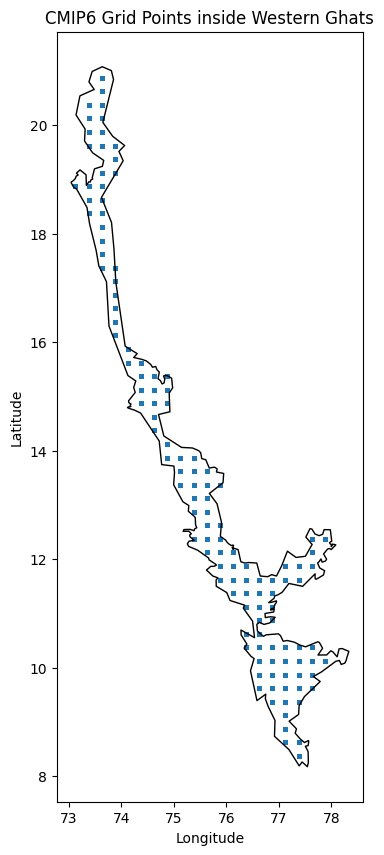

In [11]:


fig, ax = plt.subplots(figsize=(7, 10))

# Plotting Western Ghats boundary
wg.boundary.plot(ax=ax, color="black", linewidth=1)

# Plotting grid points
ax.scatter(
    df_wg["lon"],
    df_wg["lat"],
    s=5,
    alpha=0.6
)

ax.set_title("CMIP6 Grid Points inside Western Ghats")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.savefig('grid_points.png', dpi=300, bbox_inches='tight')
plt.show()



In [12]:
# loadind filtered cmip6 dataset
wg_pr = gpd.read_file(r"/content/drive/MyDrive/EC-Earth3_SSP245_WesternGhats_ONLY.csv")

In [ ]:
wg_pr.head(100)

,time,lat,lon,pr_mm_day
0,2025-01-01 12:00:00,8.375,77.375,0.0
1,2025-01-01 12:00:00,8.625,77.125,0.0
2,2025-01-01 12:00:00,8.625,77.375,0.0
3,2025-01-01 12:00:00,8.875,77.125,0.0
4,2025-01-01 12:00:00,9.125,77.125,0.0
...,...,...,...,...
95,2025-01-01 12:00:00,16.375,73.875,0.0
96,2025-01-01 12:00:00,16.625,73.875,0.0
97,2025-01-01 12:00:00,16.875,73.875,0.0
98,2025-01-01 12:00:00,17.125,73.875,0.0


In [13]:
wg_pr.dtypes


,0
time,object
lat,object
lon,object
pr_mm_day,object


In [14]:
wg_pr["pr_mm_day"] = pd.to_numeric(
    wg_pr["pr_mm_day"],
    errors="coerce"
)


In [ ]:
zero_rainfall_count = (wg_pr["pr_mm_day"] == 0.0).sum()
total_days = len(wg_pr)
percentage_zero_rainfall = (zero_rainfall_count / total_days) * 100

print(f"Percentage of zero rainfall days: {percentage_zero_rainfall:.2f}%")

Percentage of zero rainfall days: 57.07%


In [ ]:
print("Maximum rainfall:", wg_pr["pr_mm_day"].max())

Maximum rainfall: 1234.6532


In [ ]:
wg_pr.sort_values("pr_mm_day", ascending=False).head(25)


,time,lat,lon,pr_mm_day
1702952,2062-04-20 12:00:00,13.875,75.125,1234.65320
1702948,2062-04-20 12:00:00,13.625,75.125,1176.71480
2752709,2085-04-17 12:00:00,14.875,74.875,1127.12570
2420152,2078-01-04 12:00:00,10.375,77.125,1057.39620
2615709,2082-04-17 12:00:00,14.875,74.875,1013.21936
3298704,2097-04-02 12:00:00,14.125,74.875,888.35360
2752702,2085-04-17 12:00:00,13.875,75.125,811.60760
1928954,2067-04-02 12:00:00,14.125,74.875,810.02340
879827,2044-04-09 12:00:00,13.875,75.125,776.84106
2615702,2082-04-17 12:00:00,13.875,75.125,742.80853


In [ ]:
wg_pr["pr_mm_day"].describe(percentiles=[0.99, 0.999])


,pr_mm_day
count,3.469750e+06
mean,5.730387e+00
std,1.353075e+01
min,0.000000e+00
50%,0.000000e+00
99%,5.806101e+01
99.9%,1.307457e+02
max,1.234653e+03


In [ ]:

import xarray as xr

# Open the original NetCDF for that year
ds = xr.open_dataset(
    "/content/drive/MyDrive/CMIP6_WesternGhats_EC-Earth3_SSP245/EC-Earth3_r1i1p1f1_ssp245/pr_EC-Earth3_r1i1p1f1_ssp245_2062.nc")

# Extract nearest grid value
val = ds["pr"].sel(
    time="2062-04-20",
    lat=13.875,
    lon=75.125,
    method="nearest"
).values * 86400

print(val)

ds.close()


1234.6532


In [15]:
#converting time column to datetime data type
wg_pr = wg_pr[["time", "lat", "lon", "pr_mm_day"]].copy()

wg_pr["time"] = pd.to_datetime(wg_pr["time"])
wg_pr["year"] = wg_pr["time"].dt.year

In [16]:
# Safety check
assert wg_pr["time"].notna().all(), "Some time values could not be parsed"


In [17]:
wg_pr.dtypes

,0
time,datetime64[ns]
lat,object
lon,object
pr_mm_day,float64
year,int32


In [18]:
wg_pr["lat"] = pd.to_numeric(wg_pr["lat"], errors="coerce")
wg_pr["lon"] = pd.to_numeric(wg_pr["lon"], errors="coerce")


In [19]:
wg_pr["lat"] = wg_pr["lat"].astype("float32")
wg_pr["lon"] = wg_pr["lon"].astype("float32")
wg_pr["year"] = wg_pr["year"].astype("int16")


In [20]:
wg_pr.dtypes

,0
time,datetime64[ns]
lat,float32
lon,float32
pr_mm_day,float64
year,int16


In [21]:
wg_pr.dtypes

,0
time,datetime64[ns]
lat,float32
lon,float32
pr_mm_day,float64
year,int16


In [22]:
wg_pr.head(25)

,time,lat,lon,pr_mm_day,year
0,2025-01-01 12:00:00,8.375,77.375,0.0,2025
1,2025-01-01 12:00:00,8.625,77.125,0.0,2025
2,2025-01-01 12:00:00,8.625,77.375,0.0,2025
3,2025-01-01 12:00:00,8.875,77.125,0.0,2025
4,2025-01-01 12:00:00,9.125,77.125,0.0,2025
5,2025-01-01 12:00:00,9.375,76.875,0.0,2025
6,2025-01-01 12:00:00,9.375,77.125,0.0,2025
7,2025-01-01 12:00:00,9.375,77.375,0.0,2025
8,2025-01-01 12:00:00,9.625,76.625,0.0,2025
9,2025-01-01 12:00:00,9.625,76.875,0.0,2025


In [23]:
wg_pr["year"].tail()

,year
3469745,2100
3469746,2100
3469747,2100
3469748,2100
3469749,2100



### Temporal Aggregation
Daily precipitation values are aggregated to **annual totals for each grid point**, producing a continuous 76-year time series (2025–2100) at every retained location. This aggregation reduces daily-scale noise and allows robust analysis of long-term rainfall variability and trends.

The resulting dataset forms the basis for section-wise climatological analysis, climate window comparison, and trend assessment.

### Western Ghats Sections
The retained grid points are further classified into three sub-regions based on latitude:
- **North Western Ghats**
- **Central Western Ghats**
- **South Western Ghats**

Section	Latitude Range: (Reference: https://pmc.ncbi.nlm.nih.gov/articles/PMC10130714/)
South WG	lat < 11
Central WG	11 ≤ lat < 15.8
North WG	lat ≥ 15.8

### Climate Window Aggregation

To assess long-term changes in rainfall while minimizing the influence of interannual variability, precipitation has been nalyzed using **climate time windows** rather than individual years.

Three future climate windows have been defined for analysis here:
- **2025–2050** (near future)
- **2051–2075** (mid-century)
- **2076–2100** (late century)

Annual rainfall totals for each grid point has been grouped into these windows and averaged within each Western Ghats section. This approach smooths short-term variability, enhances the detection of systematic changes in rainfall characteristics and enables comparison of projected rainfall conditions across different future periods under the SSP245 scenario.



**Group** & **aggregate**


In [24]:
annual_point = (
    wg_pr
    .groupby(["lat", "lon", "year"], as_index=False)
    ["pr_mm_day"]
    .sum()
    .rename(columns={"pr_mm_day": "annual_pr_mm"})
)


In [25]:
annual_point.head()


,lat,lon,year,annual_pr_mm
0,8.375,77.375,2025,1637.437392
1,8.375,77.375,2026,1387.512855
2,8.375,77.375,2027,1077.742292
3,8.375,77.375,2028,1372.699873
4,8.375,77.375,2029,1705.965870


In [26]:
annual_point.describe()


,lat,lon,year,annual_pr_mm
count,9500.000000,9500.000000,9500.000000,9500.000000
mean,13.581000,75.591003,2062.500000,2092.948329
std,3.463259,1.444494,21.938566,823.802460
min,8.375000,73.125000,2025.000000,272.864502
25%,10.625000,74.125000,2043.750000,1472.581316
50%,12.375000,75.625000,2062.500000,2004.874226
75%,15.875000,76.875000,2081.250000,2594.038794
max,20.875000,77.875000,2100.000000,6453.220691


In [27]:
annual_point.groupby(["lat", "lon"])["year"].count().describe()


,year
count,125.0
mean,76.0
std,0.0
min,76.0
25%,76.0
50%,76.0
75%,76.0
max,76.0


**Section-wise aggregation of Western Ghats rainfall**

In [28]:
def assign_wg_section(lat):
    if lat > 15.8:
        return "North WG"
    elif lat > 11.0:
        return "Central WG"
    else:
        return "South WG"


In [34]:
SECTION_COLORS = {
    "North WG": "#1f77b4",    # blue
    "Central WG": "#2ca02c",  # green
    "South WG": "#d62728"     # red
}


In [29]:
annual_point["wg_section"] = annual_point["lat"].apply(assign_wg_section)


In [30]:
annual_point["wg_section"].value_counts()


,count
wg_section,
Central WG,4484
South WG,2584
North WG,2432


In [31]:
annual_point.groupby("wg_section")["lat"].agg(["min", "max"])


,min,max
wg_section,,
Central WG,11.125,15.625
North WG,15.875,20.875
South WG,8.375,10.875


In [32]:
section_annual = (
    annual_point
    .groupby(["wg_section", "year"], as_index=False)
    ["annual_pr_mm"]
    .mean()
)


In [33]:
section_annual.head()


,wg_section,year,annual_pr_mm
0,Central WG,2025,2219.925369
1,Central WG,2026,2091.168946
2,Central WG,2027,1495.362135
3,Central WG,2028,2102.818242
4,Central WG,2029,2875.154565


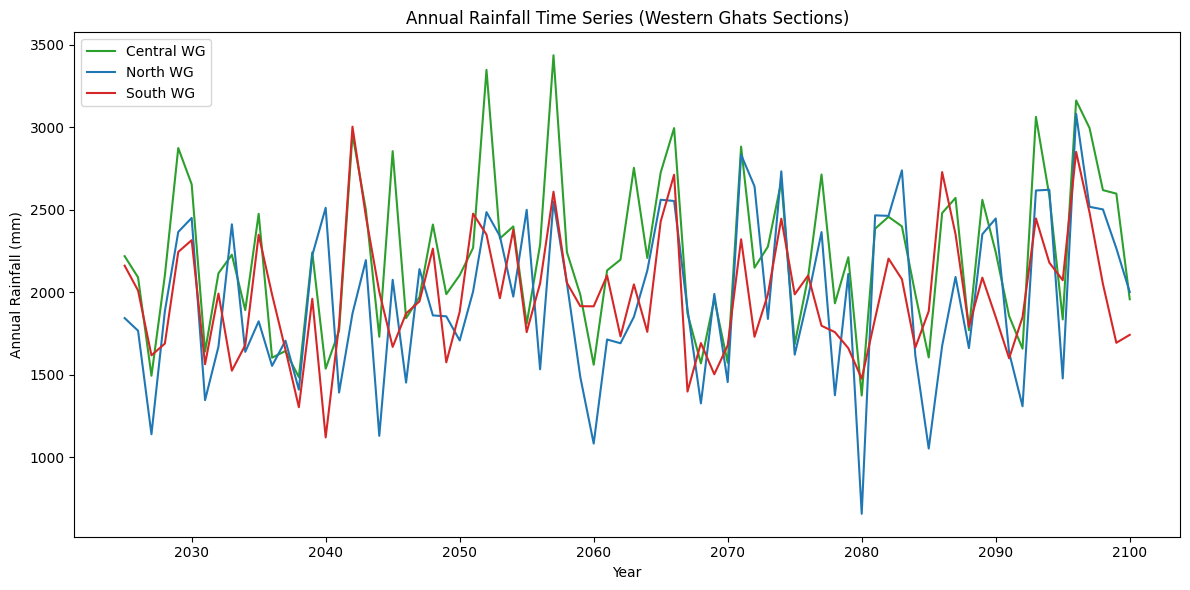

In [69]:


plt.figure(figsize=(12,6))

for sec, df in section_annual.groupby("wg_section"):
    plt.plot(df["year"], df["annual_pr_mm"], label=sec, color=SECTION_COLORS[sec])

plt.xlabel("Year")
plt.ylabel("Annual Rainfall (mm)")
plt.title("Annual Rainfall Time Series (Western Ghats Sections)")
plt.legend()
plt.tight_layout()
plt.savefig('annual_rainfall_trend.png', dpi=300, bbox_inches='tight')
plt.show()


Section-wise annual rainfall time series (2025–2100) shows strong interannual variability across all Western Ghats sections under SSP245. Central Western Ghats consistently records higher rainfall compared to North and South sections, reflecting stronger orographic influence. No clear monotonic trend is visually evident, though late-century years exhibit increased variability.


**CLIMATE WINDOW AGGREGATION**

In [42]:
def climate_window(year):
    if 2025 <= year <= 2050:
        return "2025–2050"
    elif 2051 <= year <= 2075:
        return "2051–2075"
    elif 2076 <= year <= 2100:
        return "2076–2100"
    else:
        return None


In [43]:
section_annual["climate_window"] = section_annual["year"].apply(climate_window)

section_annual = section_annual.dropna(subset=["climate_window"])


In [44]:
section_annual["climate_window"].value_counts()


,count
climate_window,
2025–2050,78
2051–2075,75
2076–2100,75


In [45]:
section_climate = (
    section_annual
    .groupby(["wg_section", "climate_window"])["annual_pr_mm"]
    .mean()
    .reset_index()
)


In [46]:
section_climate


,wg_section,climate_window,annual_pr_mm
0,Central WG,2025–2050,2094.245925
1,Central WG,2051–2075,2293.813124
2,Central WG,2076–2100,2285.776816
3,North WG,2025–2050,1825.343127
4,North WG,2051–2075,2035.124289
5,North WG,2076–2100,2044.095951
6,South WG,2025–2050,1910.629923
7,South WG,2051–2075,2041.335631
8,South WG,2076–2100,2010.996363


In [65]:
import contextily as ctx

In [66]:
# Converting annual_point to GeoDataFrame, as it contains the lat/lon for each point
gdf_points = gpd.GeoDataFrame(
    annual_point,
    geometry=gpd.points_from_xy(
        annual_point.lon,
        annual_point.lat
    ),
    crs="EPSG:4326"
)

# Reproject
wg = wg.to_crs(epsg=3857)
gdf_points = gdf_points.to_crs(epsg=3857)

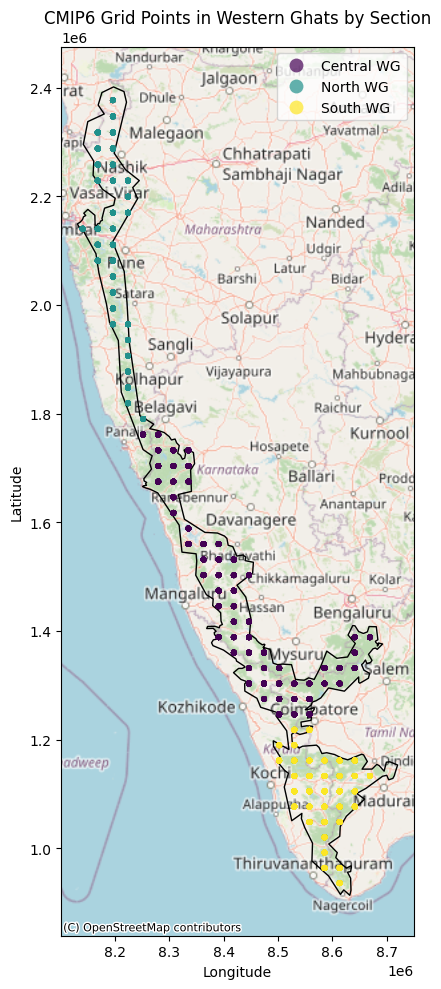

In [67]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plotting the Western Ghats boundary
wg.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1)

# Plotting grid points, colored by wg_section
gdf_points.plot(
    ax=ax,
    column='wg_section',
    cmap='viridis',
    markersize=10,
    legend=True,
    categorical=True,
    alpha=0.7
)

# Add a basemap
ctx.add_basemap(ax, crs=gdf_points.crs, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title("CMIP6 Grid Points in Western Ghats by Section")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.savefig('western_ghats_grid_points_by_section.png', dpi=300)
plt.show()

**PIVOT TABLE**

In [47]:
climate_pivot = section_climate.pivot(
    index="wg_section",
    columns="climate_window",
    values="annual_pr_mm"
)

climate_pivot


climate_window,2025–2050,2051–2075,2076–2100
wg_section,,,
Central WG,2094.245925,2293.813124,2285.776816
North WG,1825.343127,2035.124289,2044.095951
South WG,1910.629923,2041.335631,2010.996363


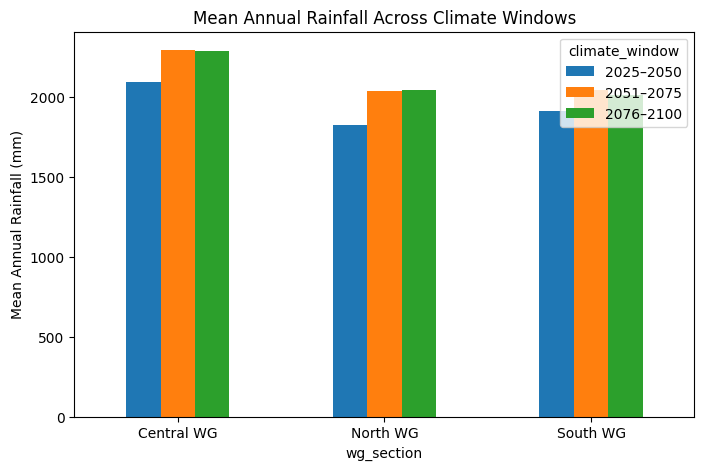

In [72]:
pivot = (
    section_annual
    .groupby(["wg_section", "climate_window"])["annual_pr_mm"]
    .mean()
    .reset_index()
    .pivot(index="wg_section", columns="climate_window", values="annual_pr_mm")
)

pivot.plot(
    kind="bar",
    figsize=(8, 5),
    ylabel="Mean Annual Rainfall (mm)",
    title="Mean Annual Rainfall Across Climate Windows"
)

plt.xticks(rotation=0)
plt.savefig('Mean_Annual_Across_Climate_Windows.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Climate window aggregation reveals a clear increase in mean annual rainfall from the early (2025–2050) to mid-century (2051–2075) period across all Western Ghats sections under SSP245. Central Western Ghats consistently exhibits the highest rainfall, while North and South sections show moderate late-century stabilization. This indicates enhanced mid-century hydroclimatic intensity with spatially consistent regional patterns.


In [ ]:
section_climate.to_csv(
    "/content/drive/MyDrive/western_ghats_section_climate_normals.csv",
    index=False
)


**Section-wise descriptive statistics**

In [ ]:
desc_stats = (
    section_annual
    .groupby("wg_section")["annual_pr_mm"]
    .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
)

desc_stats


,count,mean,std,min,5%,25%,50%,75%,95%,max
wg_section,,,,,,,,,,
Central WG,76.0,2222.896612,478.624963,1375.679711,1556.193270,1853.654170,2211.356281,2564.316189,3013.277915,3437.207783
North WG,76.0,1966.308254,496.328001,658.888777,1138.460453,1632.442651,1934.854266,2421.697164,2665.773838,3082.089769
South WG,76.0,1986.640498,365.328840,1121.832701,1497.468396,1722.256404,1963.251922,2215.238320,2636.242334,3004.479125


<Figure size 800x500 with 0 Axes>

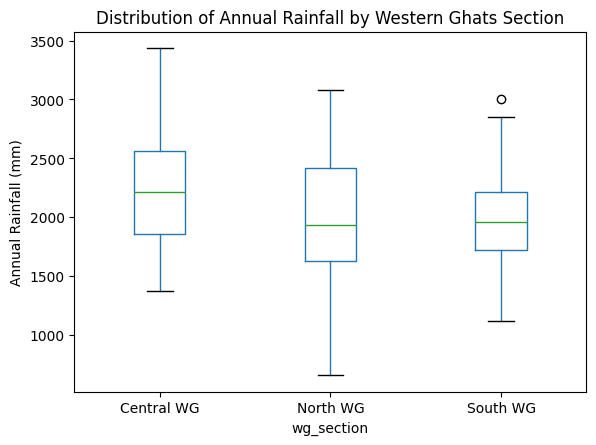

In [ ]:
plt.figure(figsize=(8, 5))

section_annual.boxplot(
    column="annual_pr_mm",
    by="wg_section",
    grid=False
)

plt.ylabel("Annual Rainfall (mm)")
plt.title("Distribution of Annual Rainfall by Western Ghats Section")
plt.suptitle("")
plt.show()


Descriptive statistics indicate that Central Western Ghats receives the highest mean annual rainfall with greater interannual variability, reflected by a larger standard deviation and higher upper-tail extremes. North and South Western Ghats show comparatively lower means.While receiving lower mean annual rainfall compared to the Central section, the NWG shows significant variability.Overall, the distributions highlight strong spatial heterogeneity and pronounced rainfall extremes across Western Ghats sections.


**TREND ANALYSIS**

In [50]:
!pip install pymannkendall


In [51]:
import pymannkendall as mk


**Mann Kendall + Sen’s slope (ANNUAL scale)**




In [52]:
trend_results = []

for section in section_annual["wg_section"].unique():
    ts = (
        section_annual
        .loc[section_annual["wg_section"] == section]
        .sort_values("year")
    )

    mk_result = mk.original_test(ts["annual_pr_mm"])

    trend_results.append({
        "wg_section": section,
        "trend": mk_result.trend,
        "p_value": mk_result.p,
        "z_stat": mk_result.z,
        "sen_slope_mm_per_year": mk_result.slope
    })

trend_df = pd.DataFrame(trend_results)
trend_df


,wg_section,trend,p_value,z_stat,sen_slope_mm_per_year
0,Central WG,no trend,0.099775,1.645944,4.149813
1,North WG,no trend,0.067950,1.825338,5.158696
2,South WG,no trend,0.372132,0.892487,1.700014


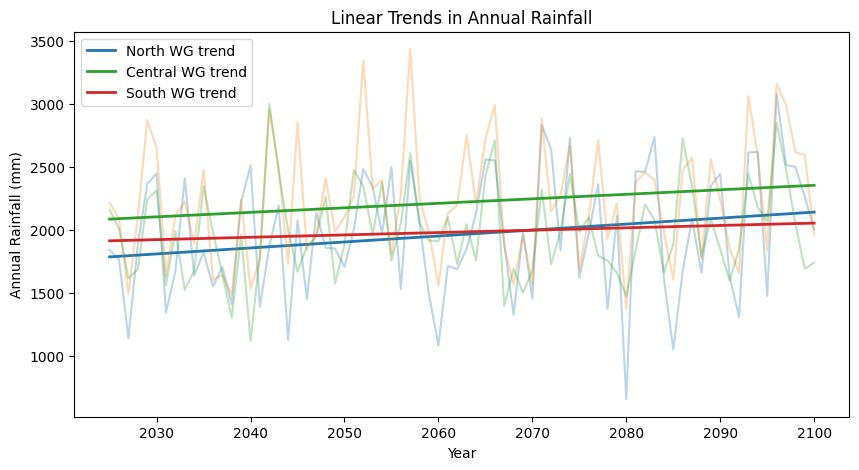

In [68]:
import numpy as np

plt.figure(figsize=(10, 5))

for sec in ["North WG", "Central WG", "South WG"]:
    df = section_annual[section_annual["wg_section"] == sec]

    # Regression
    x = df["year"].values
    y = df["annual_pr_mm"].values
    coef = np.polyfit(x, y, 1)
    trend = np.poly1d(coef)

    plt.plot(x, y, alpha=0.3)
    plt.plot(x, trend(x), linewidth=2, label=f"{sec} trend", color=SECTION_COLORS[sec])

plt.xlabel("Year")
plt.ylabel("Annual Rainfall (mm)")
plt.title("Linear Trends in Annual Rainfall")
plt.legend()
plt.savefig('Linear_Trends_in_Annual_Rainfall.png', dpi=300, bbox_inches='tight')
plt.show()


Mann–Kendall trend analysis at the annual scale indicates no statistically significant monotonic rainfall trend across all Western Ghats sections (p > 0.05). However, Sen’s slope estimates suggest a weak positive tendency, strongest in the North WG, followed by Central WG, while South WG shows minimal long-term change. This implies emerging increases in rainfall that are not yet statistically robust.


**Mann Kendall by section x climate window**



In [54]:
trend_window_results = []

for section in section_annual["wg_section"].unique():
    for window in section_annual["climate_window"].dropna().unique():

        subset = section_annual[
            (section_annual["wg_section"] == section) &
            (section_annual["climate_window"] == window)
        ].sort_values("year")

        if len(subset) < 10:
            continue  # avoid weak stats

        mk_result = mk.original_test(subset["annual_pr_mm"])

        trend_window_results.append({
            "wg_section": section,
            "climate_window": window,
            "trend": mk_result.trend,
            "p_value": mk_result.p,
            "sen_slope_mm_per_year": mk_result.slope
        })

trend_window_df = pd.DataFrame(trend_window_results)
trend_window_df


,wg_section,climate_window,trend,p_value,sen_slope_mm_per_year
0,Central WG,2025–2050,no trend,0.757640,3.320366
1,Central WG,2051–2075,no trend,0.293271,-13.984185
2,Central WG,2076–2100,no trend,0.128996,19.072872
3,North WG,2025–2050,no trend,0.964838,-0.997002
4,North WG,2051–2075,no trend,0.833516,4.752842
5,North WG,2076–2100,no trend,0.233613,19.789694
6,South WG,2025–2050,no trend,0.825548,-1.931374
7,South WG,2051–2075,no trend,0.154258,-13.935660
8,South WG,2076–2100,no trend,0.315252,11.888323


 Rainfall change in the Western Ghats is projected to be non-monotonic and characterized by high variability rather than a steady, linear trend.
 - Statistical Insignificance (No Trend): Every single window across all sections shows "no trend" (p-values > 0.05). This suggests that while rainfall may fluctuate year-to-year, there is no statistically consistent upward or downward movement within these 25-year blocks.
 - Although not yet statistically significant, the Sen's Slope magnitudes for the final window (19.07 for Central, 19.79 for North, 11.89 for South) are substantially higher than earlier windows.It suggests an acceleration of the hydrological cycle.
 - The North and Central regions show greater potential for late-century wetting, while the South is projected to experience potential drying periods mid-century.





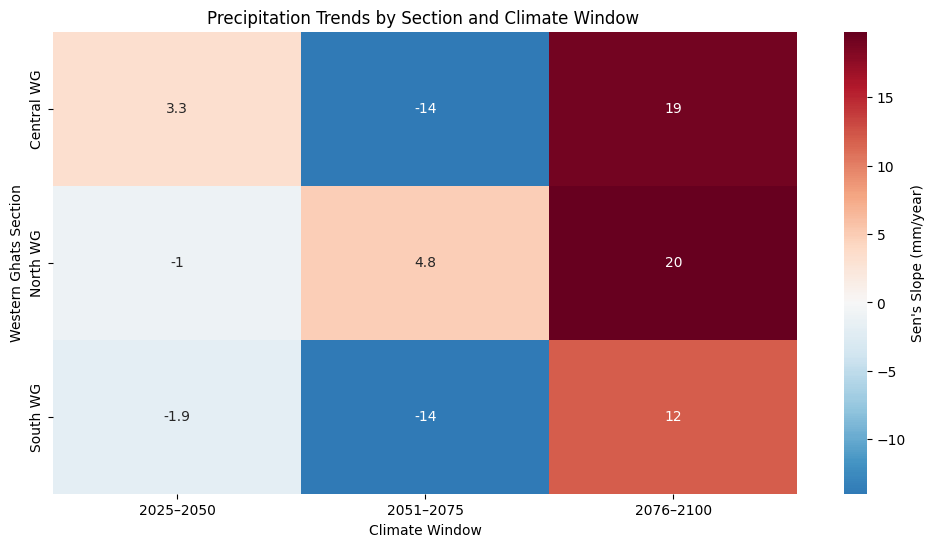

In [55]:
# 1. Pivoting the data to create a matrix (Sections as rows, Windows as columns)
pivot_df = trend_window_df.pivot(index="wg_section", columns="climate_window", values="sen_slope_mm_per_year")

# 2. Creating the heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_df, annot=True, cmap="RdBu_r", center=0, cbar_kws={'label': 'Sen\'s Slope (mm/year)'})

plt.title("Precipitation Trends by Section and Climate Window ")
plt.xlabel("Climate Window")
plt.ylabel("Western Ghats Section")

plt.savefig('trend_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

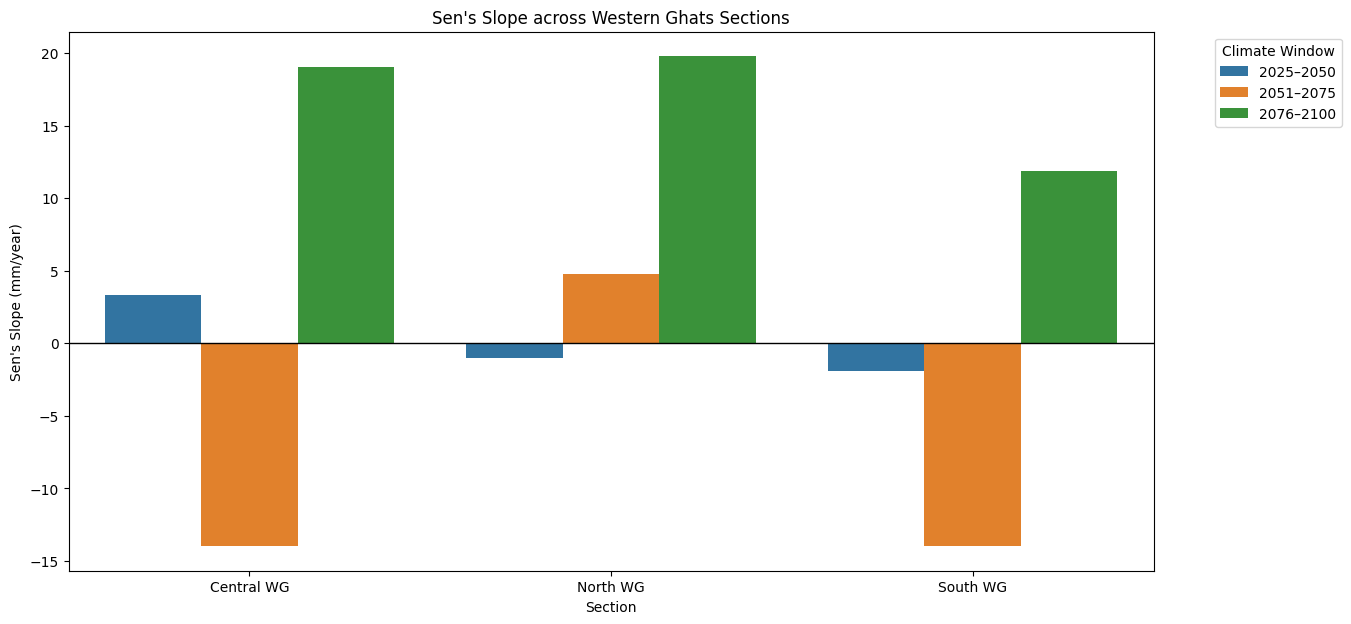

In [56]:
plt.figure(figsize=(14, 7))

# 1. Creating grouped bar chart
sns.barplot(data=trend_window_df, x="wg_section", y="sen_slope_mm_per_year", hue="climate_window")

# 2. Adding a horizontal line at 0 for reference
plt.axhline(0, color='black', linewidth=1)

plt.title("Sen's Slope across Western Ghats Sections")
plt.ylabel("Sen's Slope (mm/year)")
plt.xlabel("Section")
plt.legend(title="Climate Window", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.savefig('trend_bars.png', dpi=300, bbox_inches='tight')
plt.show()

In [62]:
import contextily as ctx

In [59]:
!pip install contextily